In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
 

In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
474,9399-APLBT,Female,0,Yes,Yes,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.70,74.7,Yes
5469,6538-POCHL,Male,0,No,No,33,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),79.00,2576.8,No
2662,8348-HFYIV,Male,0,No,No,2,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,49.25,90.35,Yes
5029,1848-LBZHY,Female,0,Yes,No,7,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),50.30,355.1,No
543,1342-JPNKI,Male,0,No,No,10,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),86.05,834.1,Yes
111,4549-ZDQYY,Female,0,No,No,52,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Credit card (automatic),57.95,3042.25,No
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
814,4785-NKHCX,Male,1,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.05,94.15,No
1638,8883-ANODQ,Female,0,Yes,Yes,68,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Two year,Yes,Credit card (automatic),84.40,5746.75,No
5845,4581-SSPWD,Female,0,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.80,246.3,Yes


In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
for col in df.columns:
    if col != 'customerID':
     print(f"Unique values of {col} ",df[col].nunique())

Unique values of gender  2
Unique values of SeniorCitizen  2
Unique values of Partner  2
Unique values of Dependents  2
Unique values of tenure  73
Unique values of PhoneService  2
Unique values of MultipleLines  3
Unique values of InternetService  3
Unique values of OnlineSecurity  3
Unique values of OnlineBackup  3
Unique values of DeviceProtection  3
Unique values of TechSupport  3
Unique values of StreamingTV  3
Unique values of StreamingMovies  3
Unique values of Contract  3
Unique values of PaperlessBilling  2
Unique values of PaymentMethod  4
Unique values of MonthlyCharges  1585
Unique values of TotalCharges  6531
Unique values of Churn  2


In [7]:
cat_clms = []

for col in df.columns:
    if df[col].nunique() < 5:
        cat_clms.append(col)

print("Categorical Columns: ",cat_clms)

Categorical Columns:  ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() < 5:
        df[col]=le.fit_transform(df[col])


In [9]:
df.sample(10
          )

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3569,9847-HNVGP,1,0,0,0,17,1,0,2,1,...,1,1,1,1,1,0,3,19.95,310.6,0
1390,8039-ACLPL,0,0,1,1,72,1,0,0,2,...,2,0,0,2,2,0,1,68.75,4888.2,0
5159,5928-QLDHB,1,0,0,0,9,1,2,1,0,...,0,0,0,0,0,1,2,76.25,684.85,0
4261,6195-MELTI,1,0,0,0,57,1,0,0,0,...,0,2,0,0,1,1,3,54.65,3134.7,0
1598,7552-KEYGT,1,0,1,0,27,1,0,2,1,...,1,1,1,1,2,0,0,19.55,520.55,0
5116,4759-TRPLW,1,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,2,70.40,70.4,1
4796,3807-BPOMJ,0,0,1,0,55,1,0,1,2,...,0,0,2,2,1,1,2,94.75,5276.1,0
6192,0439-IFYUN,0,1,0,0,18,1,0,1,0,...,0,0,0,0,0,1,2,74.70,1294.6,0
6038,1555-DJEQW,0,0,1,1,70,1,2,1,2,...,2,2,2,2,2,1,0,114.20,7723.9,1
2080,9919-FZDED,1,1,1,0,72,1,2,0,2,...,2,0,2,2,2,1,1,84.10,5981.65,0


In [10]:
for col in df.columns:
    if col != 'customerID':
     print(f"Unique values of {col} ",df[col].nunique())

Unique values of gender  2
Unique values of SeniorCitizen  2
Unique values of Partner  2
Unique values of Dependents  2
Unique values of tenure  73
Unique values of PhoneService  2
Unique values of MultipleLines  3
Unique values of InternetService  3
Unique values of OnlineSecurity  3
Unique values of OnlineBackup  3
Unique values of DeviceProtection  3
Unique values of TechSupport  3
Unique values of StreamingTV  3
Unique values of StreamingMovies  3
Unique values of Contract  3
Unique values of PaperlessBilling  2
Unique values of PaymentMethod  4
Unique values of MonthlyCharges  1585
Unique values of TotalCharges  6531
Unique values of Churn  2


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].str.strip(),
    errors='coerce'
)
print(df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

11


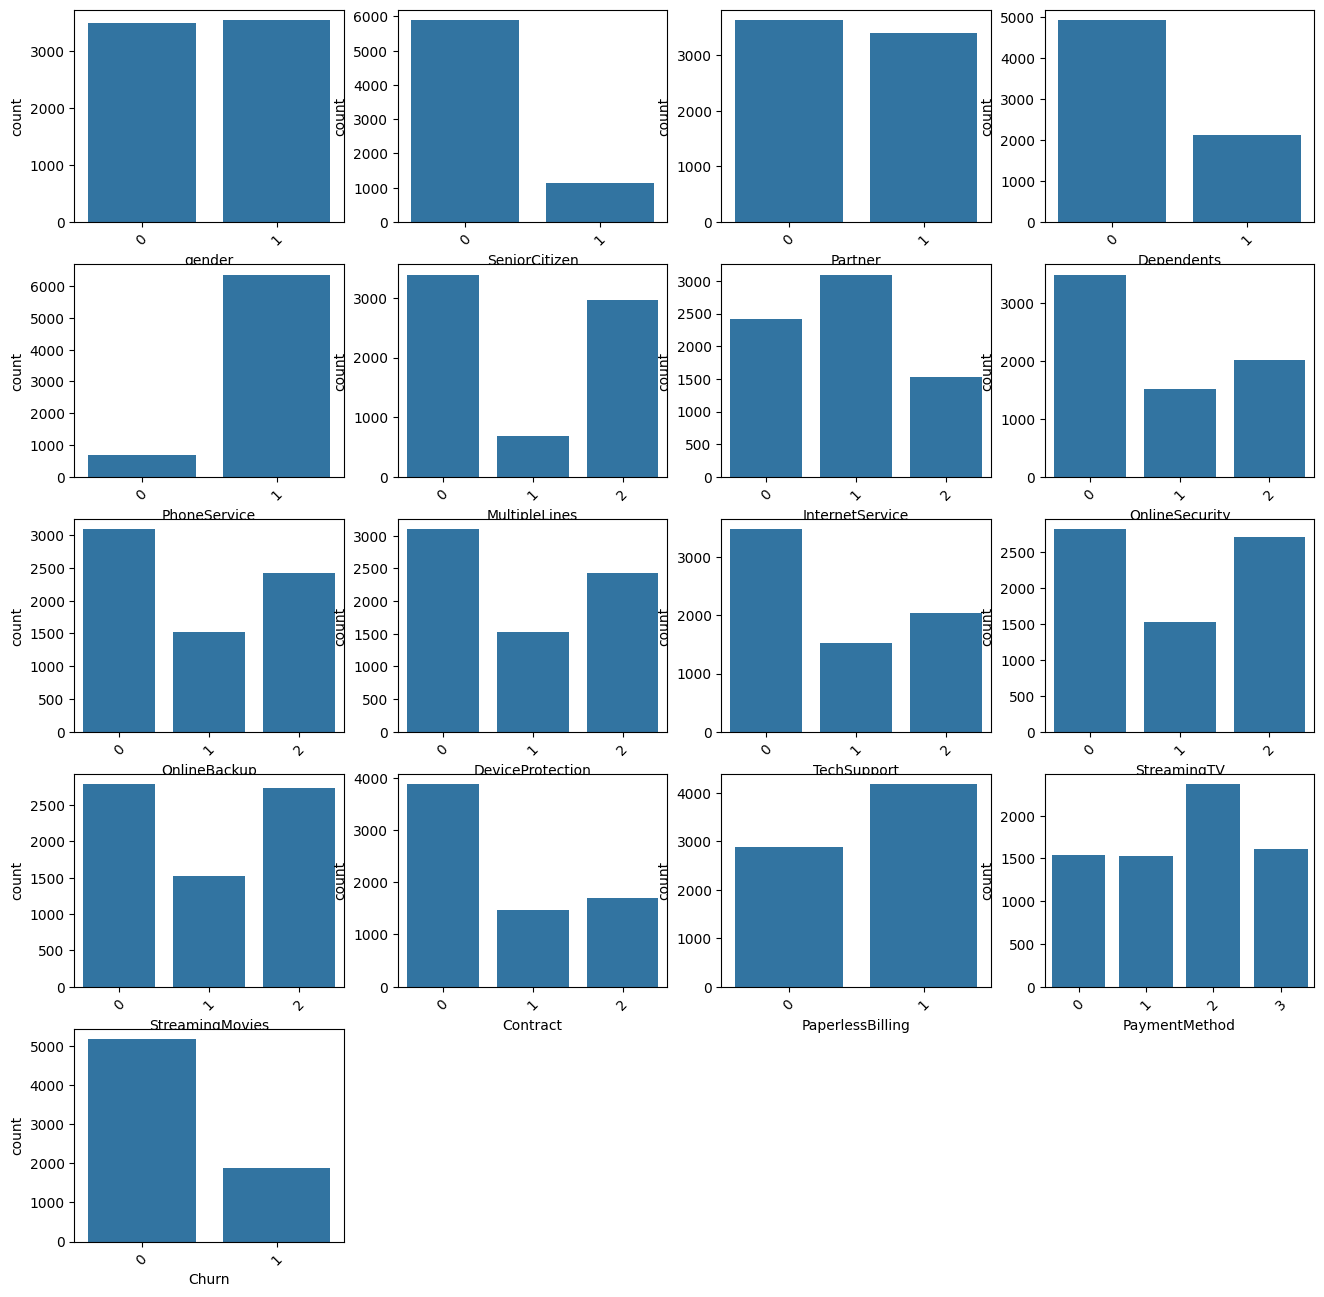

In [13]:
plt.figure(figsize=(16,16))
i=0
for col in df.columns:
    
    if df[col].nunique() < 5:
      
      plt.subplot(5, 4, i + 1)
      sns.countplot(data=df,
                  x=df[col])
      plt.xticks(rotation=45)
      
      i+=1
plt.show()
    


In [14]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)


Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [15]:
X = df.drop(['customerID','Churn'], axis=1)
y = df['Churn']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from imblearn.over_sampling import SMOTENC

cat_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

In [18]:
smote = SMOTENC(
    categorical_features=cat_indices,
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

In [19]:
print("Before SMOTENC:")
print(y_train.value_counts())

print("\nAfter SMOTENC:")
print(y_train_balanced.value_counts())

Before SMOTENC:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTENC:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)





In [21]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_balanced)

y_pred_log = log_model.predict(X_test_scaled)

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_balanced, y_train_balanced)

y_pred_dt = dt_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
acc_log=accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:",acc_log)

print(classification_report(y_test, y_pred_log))
cnf_log=confusion_matrix(y_test, y_pred_log)
print("confusion_matrix",cnf_log)

Logistic Regression Accuracy: 0.7366926898509581
              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1035
           1       0.50      0.72      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409

confusion_matrix [[770 265]
 [106 268]]


<Axes: >

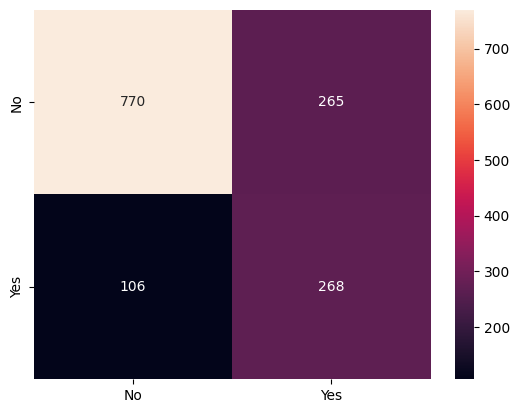

In [ ]:
sns.heatmap(cnf_log,annot=True,fmt='d',xticklabels=["No","Yes"],
    yticklabels=["No","Yes"])
plt.title("Confusion matrix of Logistic Matrix")

In [30]:
acc_dt=accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:",acc_dt)

print(classification_report(y_test, y_pred_dt))
cnf_dt=confusion_matrix(y_test, y_pred_dt)
print("confusion_matrix",cnf_dt)

Decision Tree Accuracy: 0.7097232079489
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      1035
           1       0.46      0.54      0.50       374

    accuracy                           0.71      1409
   macro avg       0.64      0.65      0.65      1409
weighted avg       0.73      0.71      0.72      1409

confusion_matrix [[799 236]
 [173 201]]


Text(0.5, 1.0, 'Confusion matrix of Decision Tree')

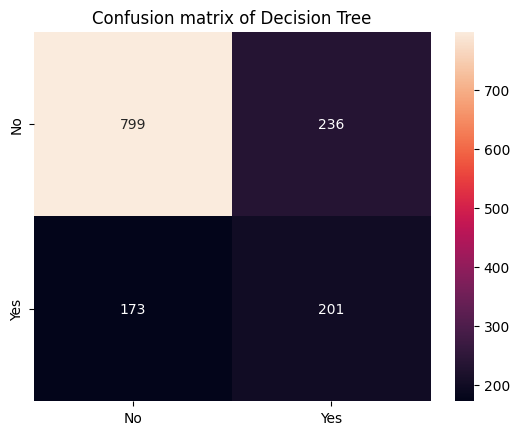

In [31]:
sns.heatmap(cnf_dt,annot=True,fmt='d',xticklabels=["No","Yes"],
    yticklabels=["No","Yes"])
plt.title("Confusion matrix of Decision Tree")

In [34]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
)

top_3 = feature_importance.sort_values(ascending=False).head(3)
print("Top 3 features driving churn:")
print(top_3)

Top 3 features driving churn:
Contract          0.276144
MonthlyCharges    0.167438
TotalCharges      0.160008
dtype: float64


Business Summary: The Decision Tree model identified Contract, MonthlyCharges,TotalCharges as the top factors associated with customer churn. This suggests that customer retention efforts should particularly focus on customers with characteristics related to these factors. The company could use these indicators to identify customers who are more likely to leave and offer targeted retention strategies. Examples include personalized offers, improved service plans, or proactive customer support. These findings can help the business prioritize its retention efforts and potentially reduce customer churn